# SARIMAX Modeling

The Neural Prophet library is not being updated. There are known issues in using Neural Prophet with newer versions of numpy. The only goal of this notebook is to try and develop a SARIMAX model instead for short term forecasting.

Our goal so far has been for 14 day forecasts, but heere, we might eve aim to do 7 day forecasts instead.

**Warning:** As wrriten, there seems to be a bug which is causing there to be very negative valued forecasts!

## Import Packages

In [11]:
import requests 
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from pandas.tseries.holiday import USFederalHolidayCalendar
import itertools
import optuna
import logging

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.holiday import USFederalHolidayCalendar


## Import Data

In [12]:
rat_sighting = pd.read_csv("../scr/data/rat_sightings_data/Rat_Sightings_NYC.csv")
rat_sighting.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in rat_sighting.columns] #apply to column headers
rat_sighting['location_type'] = rat_sighting['location_type'].str.strip().str.replace(' ', '_').str.lower()  #apply to location_type column
cols_to_drop = [c for c in rat_sighting.columns if (rat_sighting[c].nunique(dropna=False) == 1)]
rat_sighting = rat_sighting.drop(columns=cols_to_drop)
rat_sighting['created_date'] = pd.to_datetime(rat_sighting['created_date']) 
rat_sighting = rat_sighting.drop(columns='park_borough')
rat_sighting = rat_sighting.drop(columns=['location'])
rs = rat_sighting.copy()
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

lat, lon = 40.7831, -73.9712
last_date = rs['ds'].max()
start = "2020-01-01"
end   = last_date.strftime("%Y-%m-%d")  # use last date of rs

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd['ds'] = pd.to_datetime(nd['date'])
    wd = nd.drop(columns=['date'])
else:
    wd = pd.DataFrame(data["daily"])
    wd["ds"] = pd.to_datetime(wd["time"])
    wd = wd.drop(columns=["time"])

wd = wd.reset_index(drop=True)
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=14,
                             freq='D')

last_row = wd.iloc[-1]
wd_14 = pd.DataFrame([last_row.values] * 14, columns=wd.columns)
wd_14['ds'] = future_dates 
wd_14 = wd_14.reset_index(drop=True)

regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

wd["ds"] = pd.to_datetime(wd["ds"])
wd_14["ds"] = pd.to_datetime(wd_14["ds"])

rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(wd[['ds'] + regressed_features], on="ds", how="left")

rs

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_791/3708558684.py:6: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,ds,y,apparent_temperature_max,apparent_temperature_min,snowfall_sum
0,2020-01-01,17,-0.3,-5.3,0.0
1,2020-01-02,40,4.5,-6.6,0.0
2,2020-01-03,41,7.3,-1.1,0.0
3,2020-01-04,25,7.9,1.0,0.0
4,2020-01-05,17,-1.0,-5.0,0.0
...,...,...,...,...,...
2254,2026-03-04,45,6.3,-2.3,0.0
2255,2026-03-05,55,3.0,-1.2,0.0
2256,2026-03-06,47,2.3,-1.8,0.0
2257,2026-03-07,39,7.8,-0.5,0.0


## Tune Hyperparameters and Cross Validate to Check

In [13]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

tscv_splits = 3
tscv_test_size = 7


fourier_K = 3 # number of Fourier terms
yearly_period = 365.25 # accounts for leap years
weekly_seasonality = 7 # as a reminder we are using weekly seasonality




cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=rs['ds'].min(), end=rs['ds'].max())
rs['holiday'] = rs['ds'].isin(holidays).astype(int)

def fourier_series(dates, period, K):
    t = np.arange(len(dates))
    return np.column_stack([func(2 * np.pi * k * t / period)
                            for k in range(1, K+1)
                            for func in (np.sin, np.cos)])

fourier_terms = fourier_series(rs['ds'], yearly_period, fourier_K)
fourier_df = pd.DataFrame(fourier_terms, columns=[f'fourier_{i}' for i in range(fourier_terms.shape[1])])



exog = pd.concat([fourier_df, rs[['holiday'] + regressed_features].reset_index(drop=True)], axis=1)



stepwise_model = auto_arima(
    rs['y'],
    exogenous=exog,
    seasonal=True,
    m=weekly_seasonality,  # weekly seasonality
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore',
    # n_jobs=-1  # use all available CPU cores, but we must turn stepwise off. this might end up slower if you turn off stepwise
)
print("Auto ARIMA selected orders:", stepwise_model.order, stepwise_model.seasonal_order)



tscv = TimeSeriesSplit(n_splits=tscv_splits, test_size=tscv_test_size)
rmse_list = []
mape_list = []

for train_idx, test_idx in tscv.split(rs):
    y_train, y_test = rs['y'].iloc[train_idx], rs['y'].iloc[test_idx]
    exog_train, exog_test = exog.iloc[train_idx], exog.iloc[test_idx]
    
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=stepwise_model.order,
        seasonal_order=stepwise_model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    
    pred = model.get_forecast(steps=len(y_test), exog=exog_test).predicted_mean
    
    rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))
    mape_list.append(mean_absolute_percentage_error(y_test, pred))

print(f"CV Results -> Avg RMSE: {np.mean(rmse_list):.2f}, Avg MAPE: {np.mean(mape_list)*100:.2f}%")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=18070.533, Time=3.14 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=19869.506, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=19184.301, Time=0.37 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=19096.263, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=19867.507, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=18860.175, Time=2.17 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=18634.767, Time=1.29 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=6.96 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=18072.114, Time=6.08 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=18992.346, Time=0.65 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=18671.595, Time=2.64 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=18410.443, Time=2.99 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=18074.434, Time=5.01 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=18070.753, Time=2.50 sec
 ARIMA(2,1,1)(1,0,1)[7] i

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



CV Results -> Avg RMSE: 10.35, Avg MAPE: 64.20%


Auto ARIMA selected orders: (2, 1, 1) (1, 0, 1, 7).

In [14]:
exog

,fourier_0,fourier_1,fourier_2,fourier_3,fourier_4,fourier_5,holiday,apparent_temperature_max,apparent_temperature_min,snowfall_sum
0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1,-0.3,-5.3,0.0
1,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0,4.5,-6.6,0.0
2,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678,0,7.3,-1.1,0.0
3,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039,0,7.9,1.0,0.0
4,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769,0,-1.0,-5.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2254,0.879662,0.475599,0.836733,-0.547611,-0.083764,-0.996486,0,6.3,-2.3,0.0
2255,0.887713,0.460397,0.817401,-0.576069,-0.135055,-0.990838,0,3.0,-1.2,0.0
2256,0.895501,0.445059,0.797102,-0.603845,-0.185987,-0.982552,0,2.3,-1.8,0.0
2257,0.903025,0.429589,0.775859,-0.630907,-0.236424,-0.971650,0,7.8,-0.5,0.0


## Make the Final Model and Forecast

In [22]:
regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

fourier_K = 5

yearly_period = 365.25

weekly_seasonality = 7

forecast_horizon = 7 


order = (2, 1, 1) 
seasonal_order = (1, 0, 1, 7)  

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=rs['ds'].min(), end=rs['ds'].max())
rs['holiday'] = rs['ds'].isin(holidays).astype(int)

def fourier_series(dates, period, K):
    t = np.arange(len(dates))
    return np.column_stack([func(2 * np.pi * k * t / period)
                            for k in range(1, K+1)
                            for func in (np.sin, np.cos)])

fourier_terms = fourier_series(rs['ds'], yearly_period, fourier_K)
fourier_df = pd.DataFrame(fourier_terms, columns=[f'fourier_{i}' for i in range(fourier_terms.shape[1])])

exog = pd.concat([fourier_df, rs[['holiday'] + regressed_features].reset_index(drop=True)], axis=1)
sarimax_model = SARIMAX(
    rs['y'],
    exog=exog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

last_date = rs['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

last_row = rs.iloc[-1]
future_exog_df = pd.DataFrame([last_row[regressed_features + ['holiday']].values] * forecast_horizon,
                              columns=regressed_features + ['holiday'])
future_exog_df['holiday'] = future_dates.isin(holidays).astype(int)  # update holidays

future_fourier = fourier_series(future_dates, yearly_period, fourier_K)
future_fourier_df = pd.DataFrame(future_fourier, columns=fourier_df.columns)

future_exog = pd.concat([future_fourier_df.reset_index(drop=True), future_exog_df.reset_index(drop=True)], axis=1)




forecast = sarimax_model.get_forecast(steps=forecast_horizon, exog=future_exog)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()
forecast_df = pd.DataFrame({
    'ds': future_dates,
    'forecast': forecast_values,
    'lower_ci': forecast_ci.iloc[:, 0],
    'upper_ci': forecast_ci.iloc[:, 1]
})

print(forecast_df)

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



             ds    forecast    lower_ci   upper_ci
2259 2026-03-09 -101.468598 -125.976405 -76.960791
2260 2026-03-10  -98.792285 -124.347818 -73.236752
2261 2026-03-11  -96.759800 -122.819609 -70.699990
2262 2026-03-12  -96.815674 -123.049968 -70.581379
2263 2026-03-13  -95.795743 -122.131284 -69.460203
2264 2026-03-14 -105.179893 -131.586930 -78.772856
2265 2026-03-15 -106.793069 -133.260463 -80.325676


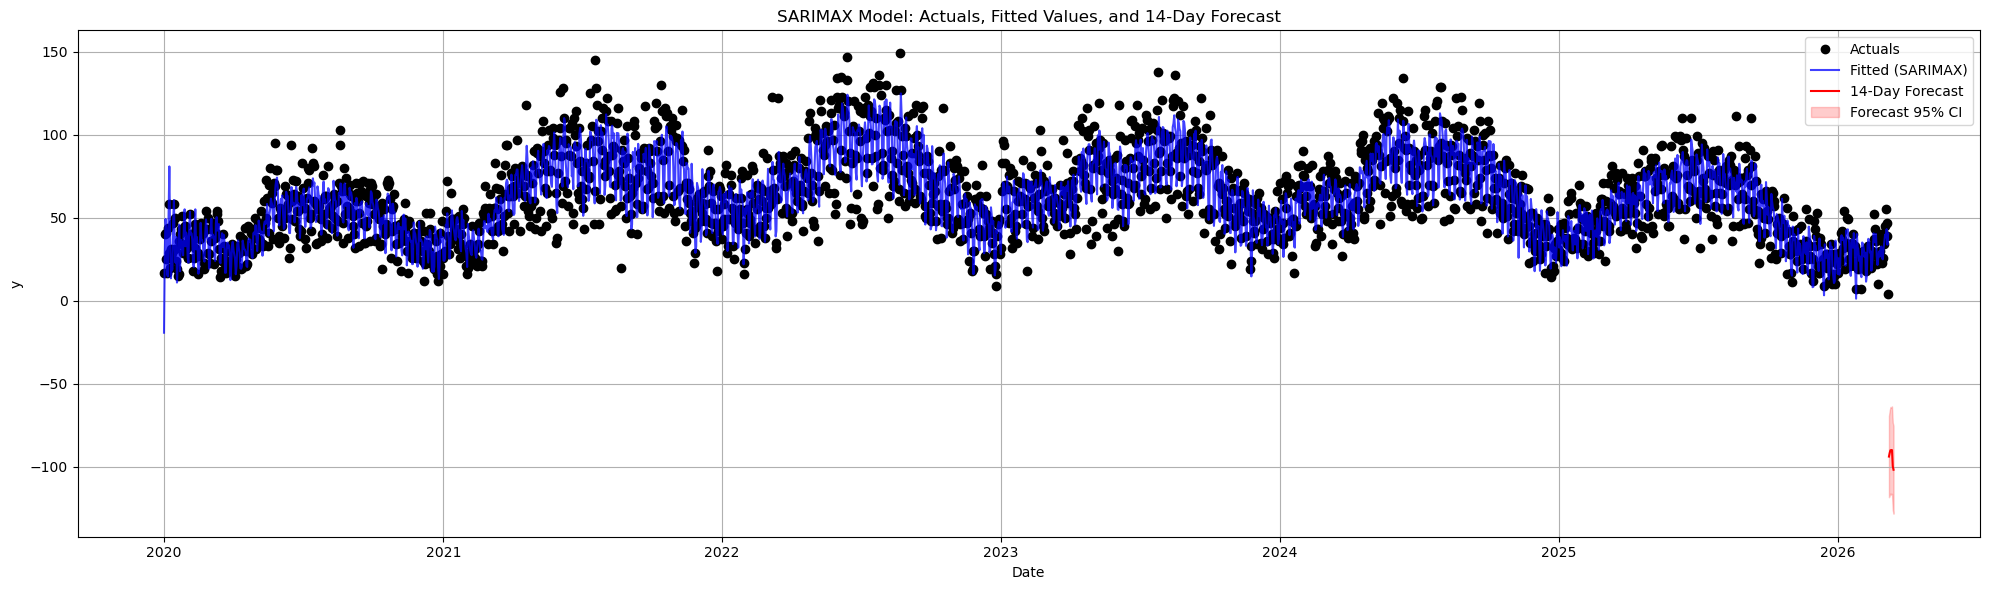

In [29]:
fitted_values = sarimax_model.fittedvalues 

plt.figure(figsize=(20,6))
plt.plot(rs['ds'], rs['y'], label='Actuals', color='black', marker = 'o', linestyle='')
plt.plot(rs['ds'], fitted_values, label='Fitted (SARIMAX)', color='blue', alpha= 0.75)
plt.plot(forecast_df['ds'], forecast_df['forecast'], label='14-Day Forecast', color='red')

plt.fill_between(forecast_df['ds'], 
                 forecast_df['lower_ci'], 
                 forecast_df['upper_ci'], 
                 color='red', alpha=0.2, label='Forecast 95% CI')

plt.xlabel('Date')
plt.ylabel('y')
plt.title('SARIMAX Model: Actuals, Fitted Values, and 14-Day Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Actuals as circles
fig.add_trace(go.Scatter(
    x=rs['ds'],
    y=rs['y'],
    mode='markers',  # dots only
    name='Actuals',
    marker=dict(color='black', size=6)
))

# Fitted values as line
fig.add_trace(go.Scatter(
    x=rs['ds'],
    y=sarimax_model.fittedvalues,
    mode='lines',
    name='Fitted (SARIMAX)',
    line=dict(color='blue', width=2),
    opacity=0.75
))

# Forecast as line
fig.add_trace(go.Scatter(
    x=forecast_df['ds'],
    y=forecast_df['forecast'],
    mode='lines',
    name='14-Day Forecast',
    line=dict(color='red', width=2)
))

# Forecast confidence interval as filled area
fig.add_trace(go.Scatter(
    x=list(forecast_df['ds']) + list(forecast_df['ds'][::-1]),
    y=list(forecast_df['upper_ci']) + list(forecast_df['lower_ci'][::-1]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Forecast 95% CI'
))

# Layout
fig.update_layout(
    title='SARIMAX Model: Actuals, Fitted Values, and 14-Day Forecast',
    xaxis_title='Date',
    yaxis_title='y',
    legend=dict(x=0, y=1),
    hovermode='x unified',
    width=1000,
    height=500
)

fig.show()

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

